# WSI Tissue Segmentation and Patch Visualization

This notebook visualizes one WSI image step by step **before generating the `.pt` file**.

It reuses the functions from `clean_dataset/WSI_folder_cleaning.py`:

1. `_create_tissue_mask()`
2. `_has_enough_tissue()`
3. `_generate_patch_coords()`
4. `_read_patch_tensors()`

The notebook only visualizes the process. It does **not** save or overwrite any `.pt` file.


## 1. Setup

Set `SVS_PATH` to one `.svs` file. If you leave it as `None`, the notebook will try to find the first `.svs` file inside `WSI_INPUT_DIR`.


In [825]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import openslide
from matplotlib.patches import Rectangle
from PIL import Image

# Robust project root detection.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "clean_dataset" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import clean_dataset.WSI_folder_cleaning as wsi_cleaning

# Reload the module so Jupyter does not use an older cached class definition.
importlib.reload(wsi_cleaning)
WSIDataCleaner = wsi_cleaning.WSIDataCleaner

# Change this path if needed.
SVS_PATH = None

# Folder to search when SVS_PATH is None.
# Put your real SVS folder here.
WSI_INPUT_DIR = Path("/media/licongcong/Data 1/TCGA-GBM/WSI-Images/ed1a696a-954b-44d3-a1c4-1578b41ab6e0")

PATCH_SIZE = 512
STRIDE = 512
MIN_TISSUE_FRACTION = 0.4

# cleaner = WSIDataCleaner()
print("Project root:", PROJECT_ROOT)
print("WSI search folder:", WSI_INPUT_DIR)

Project root: /home/licongcong/Desktop/learning/medical_image_classification/BrainCanerSurvival
WSI search folder: /media/licongcong/Data 1/TCGA-GBM/WSI-Images/ed1a696a-954b-44d3-a1c4-1578b41ab6e0


## 2. Select One WSI Slide

This cell opens one `.svs` file using OpenSlide.


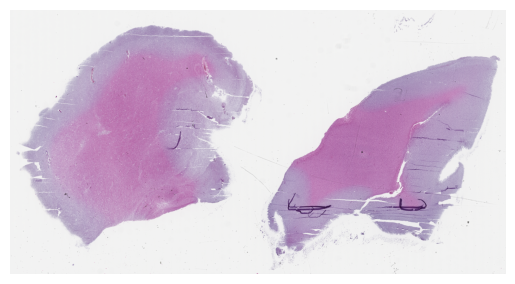

Selected WSI: /media/licongcong/Data 1/TCGA-GBM/WSI-Images/ed1a696a-954b-44d3-a1c4-1578b41ab6e0/TCGA-02-0446-01Z-00-DX2.DDC76DDC-183C-4B49-8F30-E7945BFDB0BD.svs
Original slide dimensions: 117527 x 62563
Displayed whole-slide size: (1955, 3672, 3)
Detected tissue fraction: 38.56%


In [805]:
import cv2

if SVS_PATH is None:
    svs_files = list(WSI_INPUT_DIR.rglob("*.svs"))
    if not svs_files:
        raise FileNotFoundError(
            f"No .svs files found in {WSI_INPUT_DIR}. "
            "Please set SVS_PATH manually in the setup cell."
        )
    SVS_PATH = svs_files[0]
else:
    SVS_PATH = Path(SVS_PATH)

slide = openslide.OpenSlide(str(SVS_PATH))
slide_width, slide_height = slide.dimensions

# Read the full slide region at the highest available level and resize to MASK_SIZE
level_count = slide.level_count
highest_level = level_count - 1
whole_slide_pil = slide.read_region((0, 0), highest_level, slide.level_dimensions[highest_level])
whole_slide_pil = whole_slide_pil.convert("RGB")
# whole_slide_pil = whole_slide_pil.resize((MASK_SIZE, MASK_SIZE), Image.LANCZOS)
whole_slide_np = np.array(whole_slide_pil)

# Calculate the tissue mask for the complete WSI.
tissue_mask = cleaner._create_tissue_mask(whole_slide_pil)
tissue_mask_uint8 = tissue_mask.astype(np.uint8) * 255

# Display the complete WSI and its tissue segmentation mask.
# fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.imshow(whole_slide_np)
# plt.set_title("Complete WSI")
plt.axis("off")

# axes[1].imshow(tissue_mask, cmap="gray")
# axes[1].set_title("Whole-Slide Tissue Mask")

# for ax in axes:
#     ax.axis("off")

# plt.tight_layout()
plt.savefig("../result/comparisons/whole_slide_and_tissue_mask.png", dpi=300, bbox_inches="tight")
plt.show()

print("Selected WSI:", SVS_PATH)
print("Original slide dimensions:", slide_width, "x", slide_height)
print("Displayed whole-slide size:", whole_slide_np.shape)
print("Detected tissue fraction:", f"{tissue_mask.mean():.2%}")

## 3. `_generate_patch_coords()`

This function scans the slide using a patch grid, then keeps only coordinates that pass `_has_enough_tissue()`.

Output:

```python
coords = [(x1, y1), (x2, y2), ...]
```

These are level-0 WSI coordinates.


In [806]:
# Generate all level-0 patch coordinates before removing background patches.
all_candidate_coords = []
for y in range(0, max(slide_height - PATCH_SIZE + 1, 1), STRIDE):
    for x in range(0, max(slide_width - PATCH_SIZE + 1, 1), STRIDE):
        all_candidate_coords.append((x, y))

patch_coords = cleaner._generate_patch_coords(
    slide=slide,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    mask_size=256,
    min_tissue_fraction=MIN_TISSUE_FRACTION,
)

print("All candidate patches before background removal:", len(all_candidate_coords))
print("Tissue patches after background removal:", len(patch_coords))
print("First 10 tissue patch coordinates:")
pd.DataFrame(patch_coords[:10], columns=["x", "y"])


KeyboardInterrupt: 

## 4. Visualize Patch Coordinates

Red boxes show the retained tissue patch coordinates.


MAX BOXES: 1955


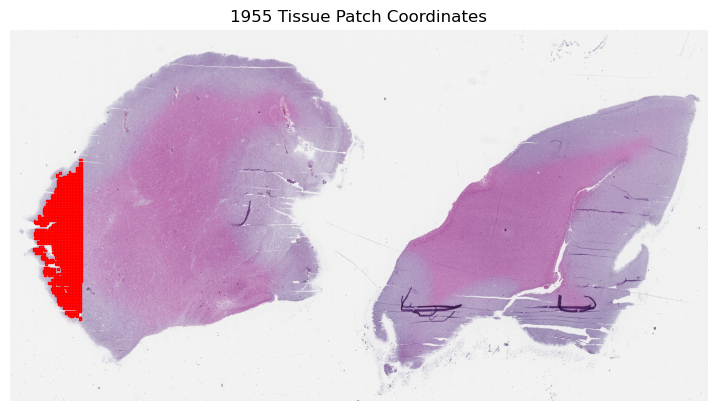

In [821]:
def draw_patch_boxes_on_thumbnail(thumbnail_np, coords, patch_size, slide_width, slide_height, max_boxes):
    thumb_height, thumb_width = thumbnail_np.shape[:2]
    scale_x = thumb_width / slide_width
    scale_y = thumb_height / slide_height
    fig, ax = plt.subplots(figsize=(9, 9))
    print("MAX BOXES:", max_boxes)
    ax.imshow(thumbnail_np)
    for x, y in coords[:max_boxes]:
        rect = Rectangle(
            (x * scale_x, y * scale_y),
            patch_size * scale_x,
            patch_size * scale_y,
            linewidth=1,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)
    ax.set_title(f"{min(len(coords), max_boxes)} Tissue Patch Coordinates")
    ax.axis("off")
    plt.savefig("../result/comparisons/path_coordinate.jpg")
    plt.show()

draw_patch_boxes_on_thumbnail(
    whole_slide_np,
    patch_coords,
    patch_size=PATCH_SIZE,
    slide_width=slide_width,
    slide_height=slide_height,
    max_boxes=len(whole_slide_np),
)

## 5. `_read_patch_tensors()`

This function reads the real image patch from the `.svs` slide at each coordinate.

Each patch is converted from:

```text
PIL image:      [H, W, C]
PyTorch tensor: [C, H, W]
```

For `PATCH_SIZE = 512`, one patch becomes:

```text
[3, 512, 512]
```


In [ ]:
# Read only a small number for visualization to keep the notebook fast.
N_VIS_PATCHES = min(12, len(patch_coords))
vis_coords = patch_coords[:N_VIS_PATCHES]
patch_tensors = cleaner._read_patch_tensors(slide, vis_coords, patch_size=PATCH_SIZE)

print("Patch tensor shape:", tuple(patch_tensors.shape))
print("Coordinate tensor shape:", (len(vis_coords), 2))

Patch tensor shape: (12, 3, 256, 256)
Coordinate tensor shape: (12, 2)


## 6. Visualize Extracted Tissue Patches

These are the actual WSI image patches that would be stored in the `.pt` file.


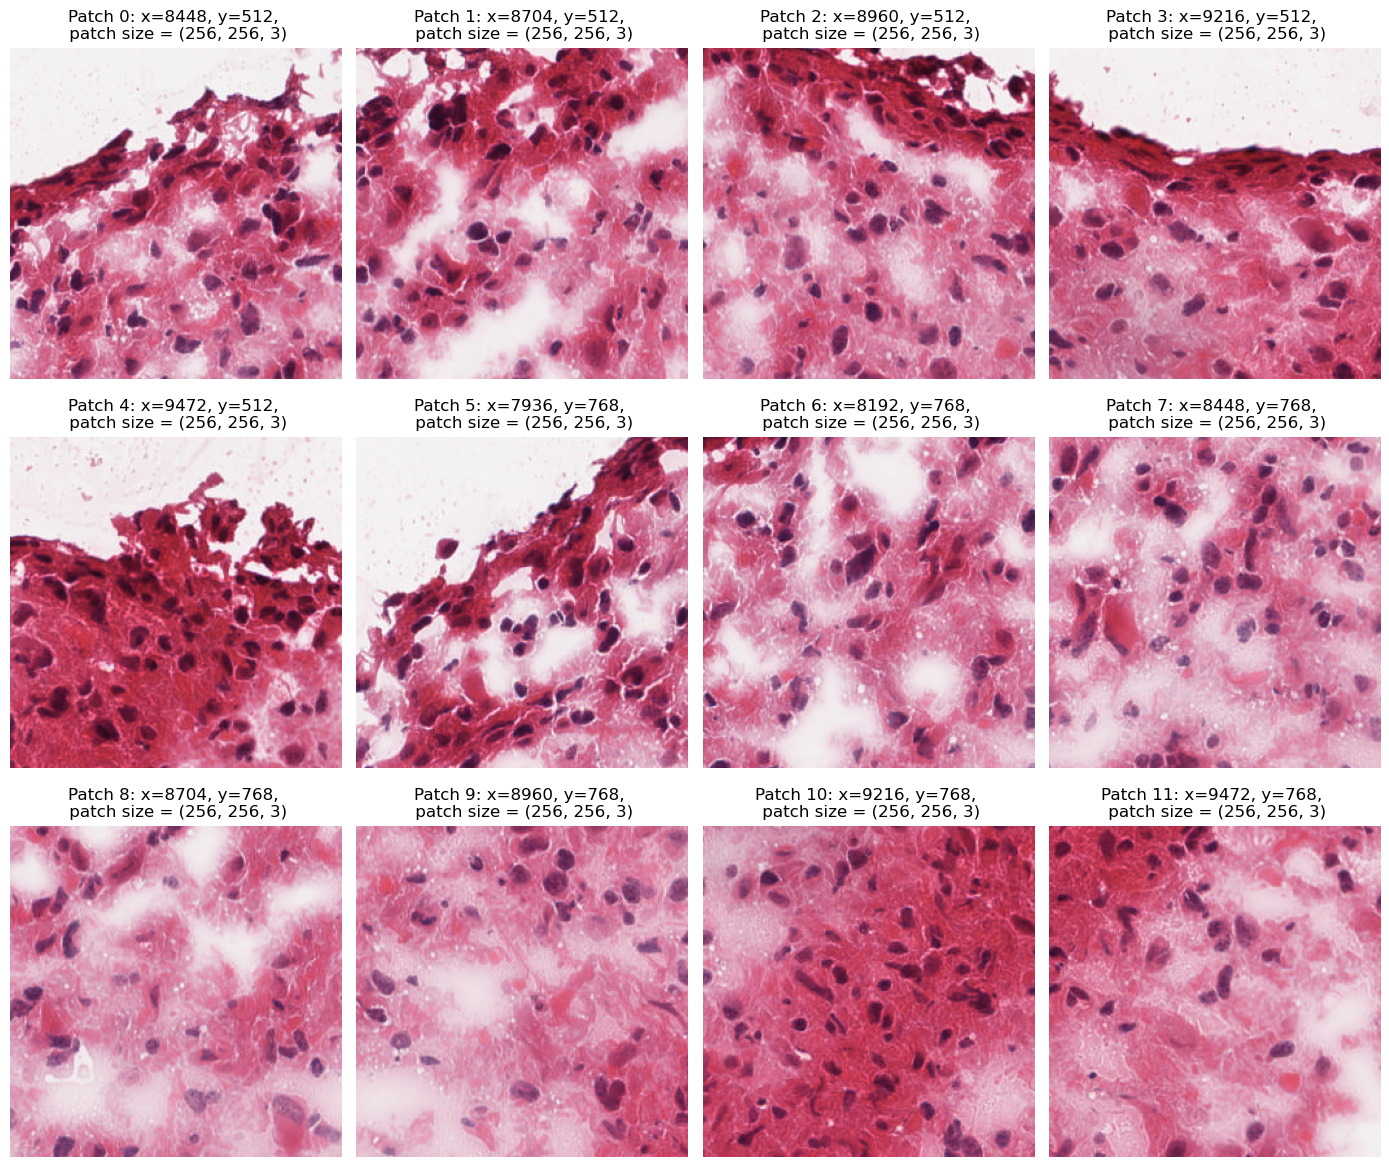

In [ ]:
if patch_tensors.shape[0] == 0:
    print("No tissue patches were found. Try lowering MIN_TISSUE_FRACTION or checking the WSI path.")
else:
    n_cols = 4
    n_rows = int(np.ceil(patch_tensors.shape[0] / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, ax in enumerate(axes):
        ax.axis("off")
        if idx >= patch_tensors.shape[0]:
            continue
        patch_img = patch_tensors[idx].permute(1, 2, 0).numpy()
        ax.imshow(patch_img)
        x, y = vis_coords[idx]
        ax.set_title(f"Patch {idx}: x={x}, y={y}, \n patch size = {patch_img.shape}")

    plt.tight_layout()
    plt.savefig("../result/comparisons/patch_details.jpg")
    plt.show()

## 6. Preview What the `.pt` File Would Contain

This cell builds the same dictionary structure used in `WSI_format_change_pt()`, but it does **not save** anything.


In [ ]:
pt_preview = {
    "patches": patch_tensors,
    "coords": torch.tensor(vis_coords, dtype=torch.long),
    "patch_size": PATCH_SIZE,
    "level": 0,
    "num_patches": int(patch_tensors.shape[0]),
    "svs_path": str(SVS_PATH),
}
for key, value in pt_preview.items():
    if torch.is_tensor(value):
        print(f"{key}: tensor shape {tuple(value.shape)}")
    else:
        print(f"{key}: {value}")

patches: tensor shape (12, 3, 256, 256)
coords: tensor shape (12, 2)
patch_size: 256
level: 0
num_patches: 12
svs_path: /media/licongcong/Data 1/TCGA-GBM/WSI-Images/0b64f778-6dd2-4c4a-87f5-94f7c21bea9d/TCGA-12-0616-01A-01-TS1.cceca29f-454d-438f-8fef-c83c31693c39.svs


## Summary

The visualization follows the same preprocessing logic used before saving `.pt` files:

```text
SVS slide
  -> thumbnail
  -> tissue mask
  -> candidate patch grid
  -> remove background patches
  -> patch coordinates
  -> read patch tensors
  -> .pt dictionary preview
```

The real saving happens only in `WSI_format_change_pt()`. This notebook only shows the intermediate steps.


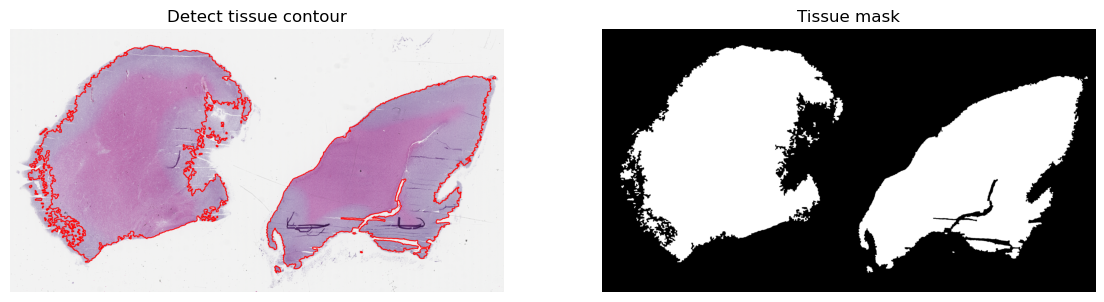

In [826]:
# tissue segementation 
# Method 2: clean the mask and segment tissue using external contours.
kernel = np.ones((7, 7), dtype=np.uint8)
clean_mask = cv2.morphologyEx(tissue_mask_uint8, cv2.MORPH_OPEN, kernel)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(
    clean_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE,
)

# Remove very small contours, which are usually noise.
min_contour_area = 1e-5 * clean_mask.shape[0] * clean_mask.shape[1]

tissue_contours = [
    contour for contour in contours
    if cv2.contourArea(contour) >= min_contour_area
]

# Build a filled binary mask from the retained tissue contours.
contour_mask = np.zeros_like(clean_mask)
cv2.drawContours(contour_mask, tissue_contours, -1, color=255, thickness=cv2.FILLED)

# Draw contour boundaries on the original thumbnail.
contour_overlay = whole_slide_np.copy()
cv2.drawContours(contour_overlay, tissue_contours, -1, color=(255, 0, 0), thickness=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(contour_overlay, cmap="gray")
axes[0].set_title("Detect tissue contour")
axes[0].axis("off")

axes[1].imshow(contour_mask, cmap="gray")
axes[1].set_title("Tissue mask")
axes[1].axis("off")
plt.savefig("../result/comparisons/contour.jpg")
plt.show()


In [808]:
# Generate all level-0 patch coordinates before removing background patches.
all_candidate_coords = []
for y in range(0, max(slide_height - PATCH_SIZE + 1, 1), STRIDE):
    for x in range(0, max(slide_width - PATCH_SIZE + 1, 1), STRIDE):
        all_candidate_coords.append((x, y))

patch_coords = cleaner._generate_patch_coords(
    slide=slide,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    mask_size=256,
    min_tissue_fraction=MIN_TISSUE_FRACTION,
)

print("All candidate patches before background removal:", len(all_candidate_coords))
print("Tissue patches after background removal:", len(patch_coords))
print("First 10 tissue patch coordinates:")
pd.DataFrame(patch_coords[:10], columns=["x", "y"])


All candidate patches before background removal: 111996
Tissue patches after background removal: 47311
First 10 tissue patch coordinates:


,x,y
0,93696,2560
1,32768,3840
2,33024,3840
3,33280,3840
4,33536,3840
5,33792,3840
6,34048,3840
7,32256,4096
8,32512,4096
9,32768,4096


Initialization create patches function 


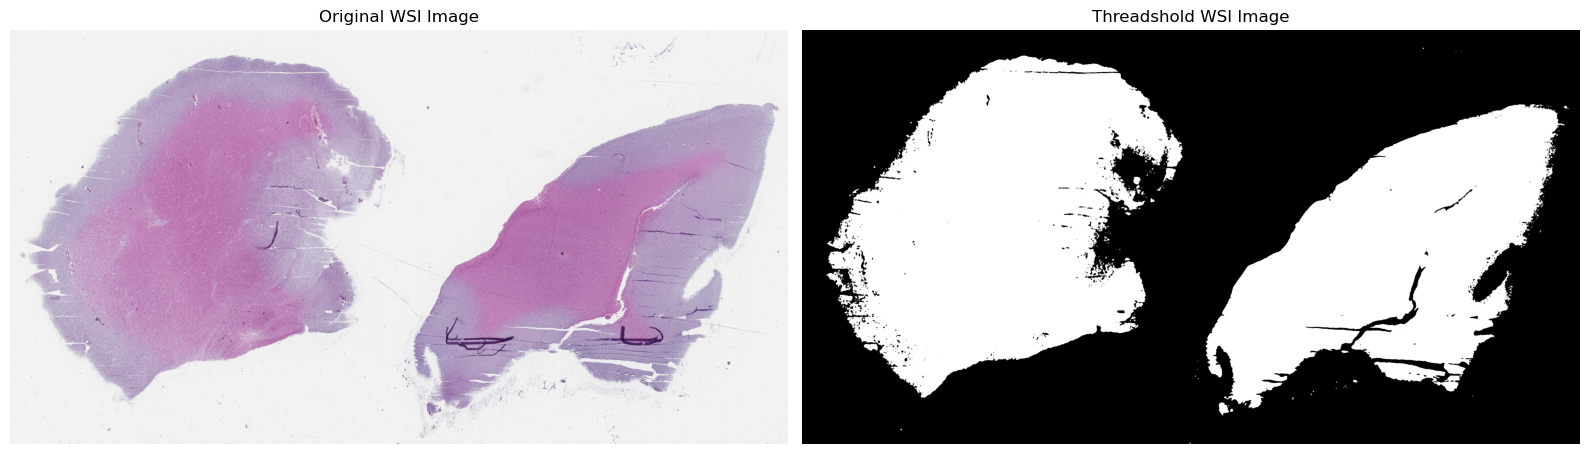

In [809]:
import importlib
import create_patches
importlib.reload(create_patches)
from create_patches import WSISegementation
import openslide

# WSI_INPUT_DIR = Path("/media/licongcong/Data 1/TCGA-GBM/WSI-Images/0b64f778-6dd2-4c4a-87f5-94f7c21bea9d")
svs_files = list(WSI_INPUT_DIR.rglob("*.svs"))
wsi = WSISegementation()
slide = openslide.OpenSlide(str(SVS_PATH))

display_level = slide.level_count - 1
slide_pil = slide.read_region((0, 0), display_level, slide.level_dimensions[display_level]).convert("RGB")
slide_np = np.array(slide_pil, dtype=np.uint8)

_, true_mask = wsi.reduce_res_threadshold(slide, display_level)
true_mask = np.asarray(true_mask, dtype=np.uint8)
# print(wsi)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(slide_np)
axes[0].set_title("Original WSI Image")

axes[1].imshow(true_mask, cmap="gray")
axes[1].set_title("Threadshold WSI Image")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [827]:

foreground_contour, hole_contour = wsi.downsample_contour(slide, true_mask, 256)

patch_coords = wsi.generate_patch_coord(patch_size=256, stride=256)
print("First 10 tissue patch coordinates:")
pd.DataFrame(patch_coords[:10], columns=["x", "y"])

Original Dimension :  ((117527, 62563), (29381, 15640), (7345, 3910), (3672, 1955))
downsample X : 32.00626361655773, downsample Y : 32.00153452685422
Print the Scale reference patch are :  63
Patch size :  256
Patch stride :  256
Count of Patch Coordination :  45648
First 10 tissue patch coordinates:


,x,y
0,3873,36770
1,3873,37026
2,4001,32002
3,4001,32258
4,4001,34050
5,4001,34306
6,4001,34562
7,4001,35074
8,4129,36770
9,4129,37026


MAX BOXES: 45648


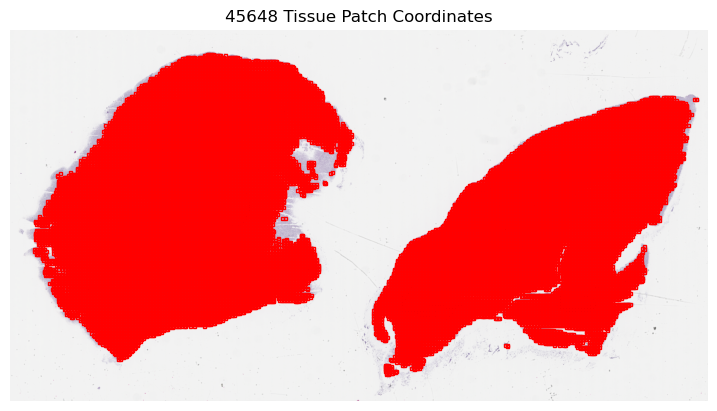

In [828]:
draw_patch_boxes_on_thumbnail(
    whole_slide_np,
    patch_coords,
    patch_size=PATCH_SIZE,
    slide_width=slide_width,
    slide_height=slide_height,
    max_boxes=45648,
)

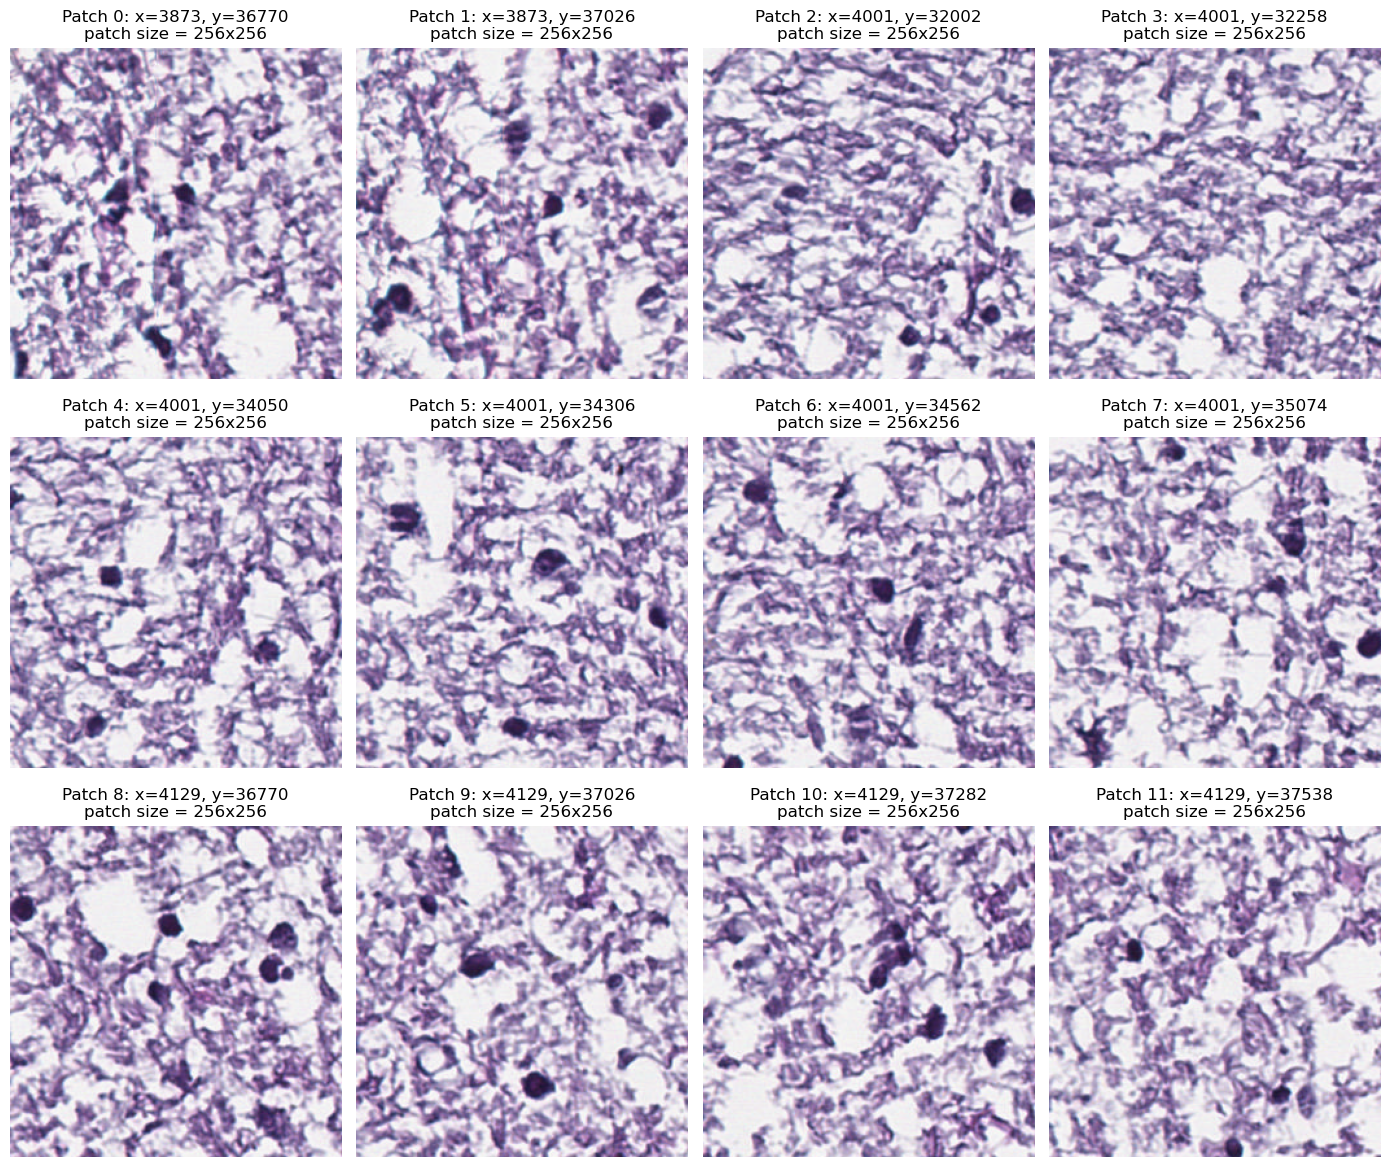

In [812]:
N_VIS_PATCHES = min(12, len(patch_coords))
vis_coords = patch_coords[:N_VIS_PATCHES]

n_cols = 4
n_rows = int(np.ceil(N_VIS_PATCHES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, ax in enumerate(axes):
    ax.axis("off")
    if idx >= N_VIS_PATCHES:
        continue

    x, y = vis_coords[idx]
    patch_img = slide.read_region(
        (int(x), int(y)),
        0,
        (PATCH_SIZE, PATCH_SIZE),
    ).convert("RGB")

    ax.imshow(patch_img)
    ax.set_title(f"Patch {idx}: x={x}, y={y}\npatch size = {PATCH_SIZE}x{PATCH_SIZE}")

plt.tight_layout()
plt.savefig("../result/comparisons/patch_details.jpg")
plt.show()